## Build your own CNN from scratch and try to achieve the highest possible accuracy on MNIST.


In [13]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307), (0.3081)),
    ]
)

In [3]:
# Importing data
train_data = torchvision.datasets.MNIST(
    root="datasets", train=True, transform=transform, download=True
)
test_data = torchvision.datasets.MNIST(
    root="datasets", train=False, transform=transform, download=True
)

In [4]:
len(train_data)

60000

In [5]:
train_data[0][0].shape

torch.Size([1, 28, 28])

In [6]:
train_data, valid_data = random_split(train_data, [55_000, 5000], torch.manual_seed(23))


In [7]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)

In [ ]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding="same", stride=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(),
            nn.Conv2d(16, 32, 3, padding="same", stride=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding="same", stride=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, 3, padding="same", stride=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.linear1 = nn.Linear(128, 256)
        self.relu1 = nn.LeakyReLU()
        self.linear2 = nn.Linear(256, 128)
        self.relu2 = nn.LeakyReLU()
        self.classifier = nn.Linear(128, 10)

    def forward(self, X):
        X = self.seq(X)
        # print(X.shape)
        X = self.gap(X)
        X = torch.flatten(
            X, 1
        )  # 1 vine de la dimensiune de la care se incepe apltaizarea
        X = self.relu1(self.linear1(X))
        X = self.relu2(self.linear2(X))
        return self.classifier(X)


In [ ]:
import time

device = "mps"


def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    predictions = []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            predictions.append(y_pred)
            metric.update(y_pred, y_batch)
    return metric.compute()


def train_with_early_stopping_lr_scheduler_warm_up(
    model,
    optimizer,
    loss_fn,
    metric,
    train_loader,
    valid_loader,
    n_epochs,
    warmup_scheduler,
    patience=10,
    checkpoint_path=None,
    scheduler=None,
):
    checkpoint_path = checkpoint_path or "my_checkpoint.pt"
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    best_metric = 0.0
    patience_counter = 0
    warmup_epochs = 3
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        t0 = time.time()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        train_metric = metric.compute().item()
        valid_metric = evaluate_tm(model, valid_loader, metric).item()
        if valid_metric > best_metric:
            torch.save(model.state_dict(), checkpoint_path)
            best_metric = valid_metric
            best = " (best)"
            patience_counter = 0
        else:
            patience_counter += 1
            best = ""

        t1 = time.time()
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        history["valid_metrics"].append(valid_metric)
        print(
            f"Epoch {epoch + 1}/{n_epochs}, "
            f"train loss: {history['train_losses'][-1]:.4f}, "
            f"train metric: {history['train_metrics'][-1]:.4f}, "
            f"valid metric: {history['valid_metrics'][-1]:.4f}{best}"
            f" in {t1 - t0:.1f}s"
        )
        if epoch < warmup_epochs:
            warmup_scheduler.step()
        if epoch >= warmup_epochs:
            if scheduler is not None:
                scheduler.step(valid_metric)
        if patience_counter >= patience:
            print("Early stopping!")
            break

    model.load_state_dict(torch.load(checkpoint_path))
    return history

In [10]:
import torchmetrics


model = MNISTClassifier().to(device)
optimizer = torch.optim.AdamW(model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1
)
warm_up_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lambda epoch: (min(epoch, 3) / 3) * (1.0 - 0.1) + 0.1
)
metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [11]:
results = train_with_early_stopping_lr_scheduler_warm_up(
    model,
    optimizer,
    loss_fn,
    metric,
    train_loader,
    valid_loader,
    n_epochs=20,
    patience=5,
    warmup_scheduler=warm_up_scheduler,
    scheduler=perf_scheduler,
)

Epoch 1/20, train loss: 0.7309, train metric: 0.7837, valid metric: 0.9434 (best) in 32.4s
Epoch 2/20, train loss: 0.1314, train metric: 0.9609, valid metric: 0.9702 (best) in 27.7s
Epoch 3/20, train loss: 0.0887, train metric: 0.9724, valid metric: 0.8504 in 27.2s
Epoch 4/20, train loss: 0.0751, train metric: 0.9767, valid metric: 0.9766 (best) in 9.7s
Epoch 5/20, train loss: 0.0597, train metric: 0.9814, valid metric: 0.9836 (best) in 10.0s
Epoch 6/20, train loss: 0.0486, train metric: 0.9852, valid metric: 0.9854 (best) in 20.6s
Epoch 7/20, train loss: 0.0433, train metric: 0.9862, valid metric: 0.9802 in 10.5s
Epoch 8/20, train loss: 0.0398, train metric: 0.9876, valid metric: 0.9778 in 17.9s
Epoch 9/20, train loss: 0.0382, train metric: 0.9874, valid metric: 0.9814 in 22.8s
Epoch 10/20, train loss: 0.0137, train metric: 0.9957, valid metric: 0.9938 (best) in 26.1s
Epoch 11/20, train loss: 0.0100, train metric: 0.9971, valid metric: 0.9938 in 28.0s
Epoch 12/20, train loss: 0.0095, 

In [ ]:
test_result = evaluate_tm(model, test_loader, metric)

tensor(0.9942, device='mps:0')

/var/folders/d8/k55r2d1s5k78lrh9j8l3lfzw0000gn/T/ipykernel_24390/4015093377.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


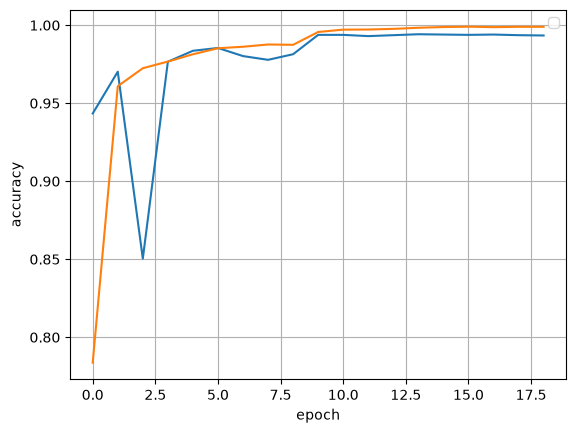

In [19]:
plt.plot(results["valid_metrics"])
plt.plot(results["train_metrics"])
plt.grid()
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()